In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
import shap
import re
import csv
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, average_precision_score, auc, RocCurveDisplay
from sklearn.model_selection import learning_curve
from Bio.SeqUtils.ProtParam import ProteinAnalysis

c:\Users\ankit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\train_data.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\val_data.csv")

In [3]:
seq_cols = ["CDR1 aligned", "CDR2 aligned", "CDR3 aligned"]
amino_acids = list("ACDEFGHIKLMNPQRSTVWY-")
add_position = True

In [4]:
def concat_cdrs(row):
    return "".join(str(row[col]) for col in seq_cols)

train_df["CDRs"] = train_df.apply(concat_cdrs, axis=1)
val_df["CDRs"] = val_df.apply(concat_cdrs, axis=1)
train_lengths = train_df["CDRs"].str.len().iloc[0]
val_lengths = val_df["CDRs"].str.len().iloc[0]

#assertions checking
assert train_lengths == val_lengths
assert (train_df["CDRs"].str.len() == train_lengths).all()
assert (val_df["CDRs"].str.len() == val_lengths).all()

In [5]:
print(train_lengths)

50


In [6]:
# one-hot encoding (identity matrix)
aa2idx = {aa: i for i, aa in enumerate(amino_acids)}
I = np.eye(len(amino_acids),dtype=np.float32) # identity matrix

In [7]:
def one_hot_encode(seq, add_position=True, dtype=np.float32):
    feats = []
    for i, a in enumerate(seq):
        v =I[aa2idx.get(a, aa2idx["-"])] #default to '-' if unknown
        if add_position:
            v = np.concatenate((v, [i/train_lengths])) #normalized position
        feats.append(v)
    return np.concatenate(feats, dtype=dtype)

In [8]:
x_train = np.vstack([one_hot_encode(seq, add_position, dtype=np.float32) for seq in train_df["CDRs"]])
y_train = train_df["Label"].values
x_val = np.vstack([one_hot_encode(seq, add_position, dtype=np.float32) for seq in val_df["CDRs"]])
y_val = val_df["Label"].values

In [9]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,              # moderate depth
    min_samples_leaf=3,       # small regularization
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)
clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [10]:
y_pred = clf.predict(x_val)
y_scores = clf.predict_proba(x_val)[:, 1]
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_val, clf.predict_proba(x_val)[:, 1]))

Accuracy: 0.5801304779463906
Precision: 0.5780439121756487
Recall: 0.6123484634902735
F1 Score: 0.5947018960914505

Confusion Matrix:
 [[3837 3171]
 [2750 4344]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.55      0.56      7008
           1       0.58      0.61      0.59      7094

    accuracy                           0.58     14102
   macro avg       0.58      0.58      0.58     14102
weighted avg       0.58      0.58      0.58     14102


ROC AUC Score: 0.6087504871793386


In [11]:
# Training predictions
y_train_pred = clf.predict(x_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Training Accuracy: 0.5814304528416574
Validation Accuracy: 0.5801304779463906


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    clf,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o")
plt.plot(train_sizes, val_mean, marker="o")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend(["Training Score", "Cross-Validation Score"])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
print("Baseline accuracy:", dummy.score(x_val, y_val))


Baseline accuracy: 0.5030492128776061


In [13]:
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)
print("Average precision:", ap)
pr_auc = auc(recall, precision)
print("PR AUC (AUC over PR curve):", pr_auc)

Average precision: 0.602372167411872
PR AUC (AUC over PR curve): 0.60218095937044


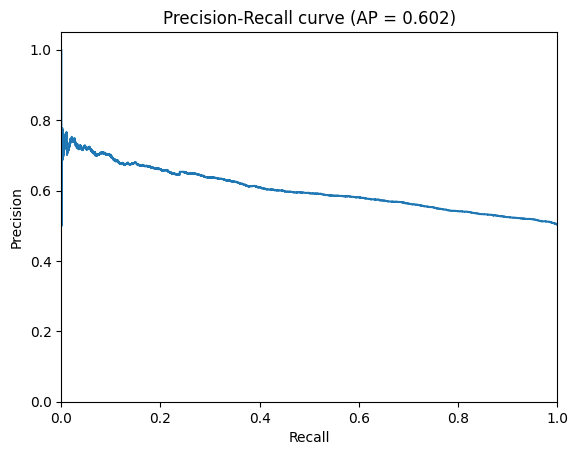

In [14]:
plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP = {ap:.3f})")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

Test evaluation

In [15]:
test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_combined_data.csv")
test_df["CDRs"] = test_df.apply(concat_cdrs, axis=1)
test_lengths = test_df["CDRs"].str.len().iloc[0]

In [16]:
#assertions checking
assert train_lengths == test_lengths
assert (test_df["CDRs"].str.len() == test_lengths).all()


In [17]:
x_test = np.vstack([one_hot_encode(seq, add_position, dtype=np.float32) for seq in test_df["CDRs"]])
y_test = test_df["Label"].values
clusters_test = test_df["Cluster_name"].values

In [18]:
y_scores_test = clf.predict_proba(x_test)[:, 1]
# labels at fixed threshold
y_pred_test = (y_scores_test >= 0.5).astype(int)

# standard metrics
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

roc_auc = roc_auc_score(y_test, y_scores_test)
p, r, _ = precision_recall_curve(y_test, y_scores_test)
pr_auc = auc(r, p)

print("\n================ FULL TEST SET================\n")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print("\nConfusion matrix:")
print(cm)
print(f"\nROC-AUC (full test):   {roc_auc:.3f}")
print(f"PR-AUC (full test):    {pr_auc:.3f}")




================ FULL TEST SET================

Accuracy:  0.570
Precision: 0.566
Recall:    0.607
F1:        0.586

Confusion matrix:
[[7452 6564]
 [5527 8554]]

ROC-AUC (full test):   0.598
PR-AUC (full test):    0.594


In [19]:
r"""
# Some sequences output

probs = y_scores_test
top100_idx = np.argsort(-probs)[:100]
low50_idx = np.argsort(probs)[:50]
uncertain50_idx = np.abs(probs - 0.5).argsort()[:50]

df_test = test_df.copy()
df_test["pred_score"] = probs
df_test["pred_label"] = (probs >= 0.5).astype(int)

cols = [
    "Cluster_name",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence",
]

df_top50 = df_test.iloc[top100_idx][cols]
df_low50 = df_test.iloc[low50_idx][cols]
df_uncertain50 = df_test.iloc[uncertain50_idx][cols]

df_top50.to_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\Predictions\top50_high_confidence.csv", index=False)
df_low50.to_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\Predictions\low50_low_confidence.csv", index=False)
df_uncertain50.to_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\Predictions\uncertain50.csv", index=False)

"""



'\n# Some sequences output\n\nprobs = y_scores_test\ntop100_idx = np.argsort(-probs)[:100]\nlow50_idx = np.argsort(probs)[:50]\nuncertain50_idx = np.abs(probs - 0.5).argsort()[:50]\n\ndf_test = test_df.copy()\ndf_test["pred_score"] = probs\ndf_test["pred_label"] = (probs >= 0.5).astype(int)\n\ncols = [\n    "Cluster_name",\n    "Nanobody_id",\n    "Label",\n    "pred_label",\n    "pred_score",\n    "Sequence",\n    "CDR1",\n    "CDR2",\n    "CDR3",\n    "CDR1 aligned",\n    "CDR2 aligned",\n    "CDR3 aligned",\n    "Aligned Sequence",\n]\n\ndf_top50 = df_test.iloc[top100_idx][cols]\ndf_low50 = df_test.iloc[low50_idx][cols]\ndf_uncertain50 = df_test.iloc[uncertain50_idx][cols]\n\ndf_top50.to_csv(r"D:\\Thesis - November\\Dataset\\Clustering\\new_90 percent\\Predictions\\top50_high_confidence.csv", index=False)\ndf_low50.to_csv(r"D:\\Thesis - November\\Dataset\\Clustering\\new_90 percent\\Predictions\\low50_low_confidence.csv", index=False)\ndf_uncertain50.to_csv(r"D:\\Thesis - November\\

In [20]:
print("\n================ Top-100 PREDICTIONS ONLY ================\n")
k =100
top_idx = np.argsort(-y_scores_test)[:k]
y_true_100 = y_test[top_idx]
tp_100 = np.sum(y_test[top_idx] == 1)
precision_100 = tp_100 / k
print(f"Precision@100: {precision_100:.3f}")
recall_100 = tp_100 / np.sum(y_test == 1)
print(f"Recall@100: {recall_100:.3f}")
n = len(y_test)
p = np.sum(y_test == 1)
ef_100 = (tp_100/k)/(p/n)
print(f"EF@100: {ef_100:.3f}")
assert len(clusters_test) == len(y_test)
diversity_100 = len(np.unique(clusters_test[top_idx]))
print(f"Diversity@100: {diversity_100}")
total_test_clusters = len(np.unique(clusters_test))
print("\nTotal clusters in test:", total_test_clusters)
normalized_diversity_100 = diversity_100 / total_test_clusters
print(f"Normalized diversity@100: {normalized_diversity_100:.3f}")
print("Top-K clusters:", np.unique(clusters_test[top_idx])[:10])

k1000 =1000
top1000_idx = np.argsort(-y_scores_test)[:k1000]
y_true_1000 = y_test[top1000_idx]
tp_1000 = np.sum(y_test[top1000_idx] == 1)
precision_1000 = tp_1000 / k1000
print(f"Precision@1000: {precision_1000:.3f}")




================ Top-100 PREDICTIONS ONLY ================

Precision@100: 0.840
Recall@100: 0.006
EF@100: 1.676
Diversity@100: 93

Total clusters in test: 26167
Normalized diversity@100: 0.004
Top-K clusters: [52827 53189 54236 54260 54546 55046 56746 56859 56903 57357]
Precision@1000: 0.713


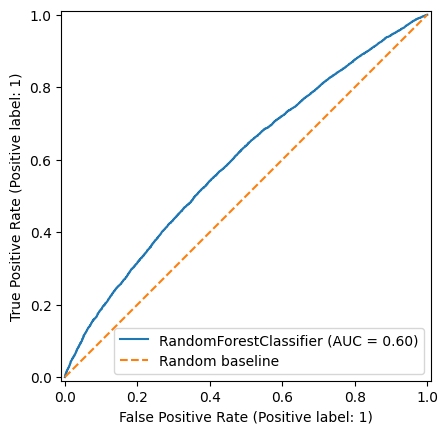

In [21]:
RocCurveDisplay.from_estimator(clf, x_test, y_test)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.legend()
plt.show()

Total test samples: 28097
ANARCII CDR positions (L): 50
Total features D=1100
Channels per position n_channels=22 (AA channels=21, extras per pos=1)
SHAP matrix shape: (28097, 1100)
min/max shap: -0.015104735474940822 0.01666074745332479


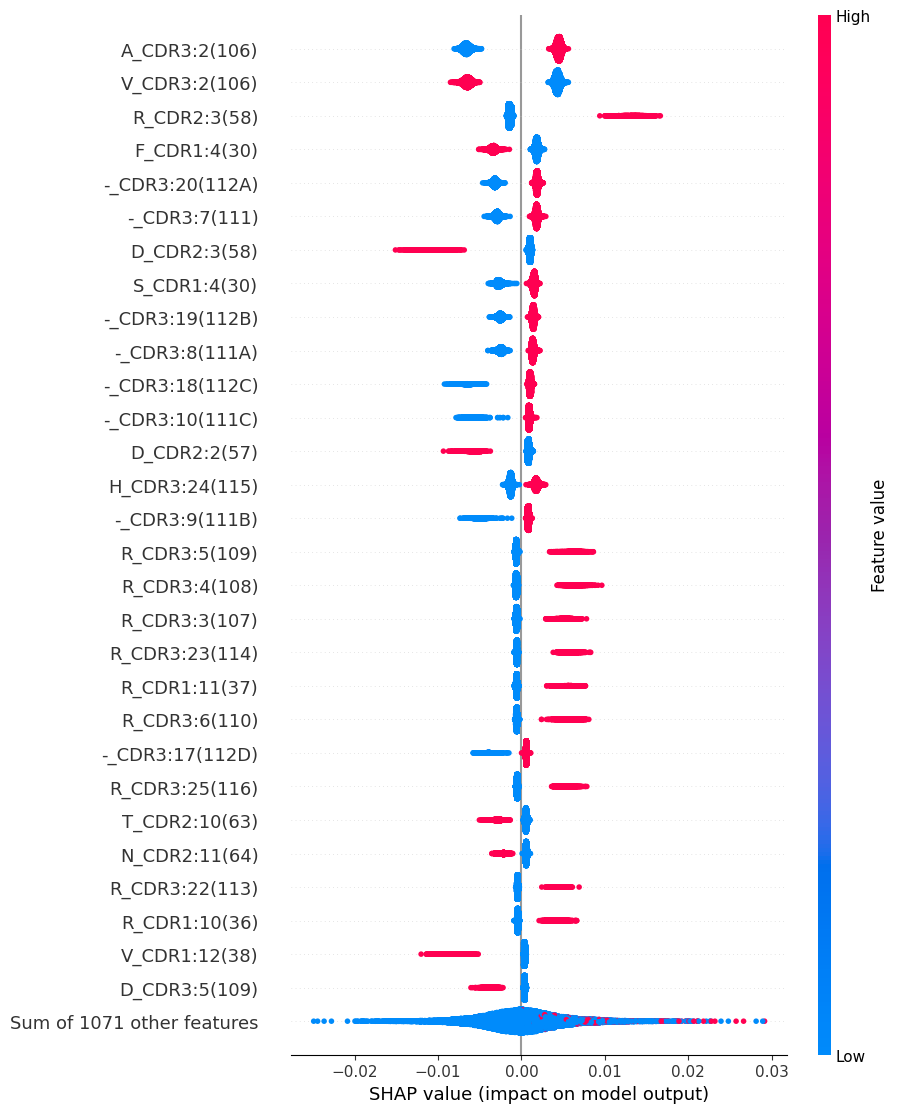


Top 20 features by |SHAP|:
        feature  mean_abs_SHAP
  A_CDR3:2(106)       0.005325
  V_CDR3:2(106)       0.005184
   R_CDR2:3(58)       0.002515
   F_CDR1:4(30)       0.002393
-_CDR3:20(112A)       0.002388
  -_CDR3:7(111)       0.002288
   D_CDR2:3(58)       0.001924
   S_CDR1:4(30)       0.001922
-_CDR3:19(112B)       0.001832
 -_CDR3:8(111A)       0.001807
-_CDR3:18(112C)       0.001778
-_CDR3:10(111C)       0.001609
   D_CDR2:2(57)       0.001523
 H_CDR3:24(115)       0.001506
 -_CDR3:9(111B)       0.001413
  R_CDR3:5(109)       0.001154
  R_CDR3:4(108)       0.001119
  R_CDR3:3(107)       0.001048
 R_CDR3:23(114)       0.001022
  R_CDR1:11(37)       0.001018


In [22]:

# =======================================================
# 0) Setup + scores
# =======================================================
rng = np.random.default_rng(0)

# Predict scores on FULL test set
y_scores_test = clf.predict_proba(x_test)[:, 1]

print("Total test samples:", x_test.shape[0])

# Feature dimension (use x_train or x_test; background not used anymore)
D = x_train.shape[1] if hasattr(x_train, "shape") else x_test.shape[1]

# =======================================================
# 1) Read ANARCII header and determine CDR ANARCII columns
# =======================================================
anarcii_path = r"D:\Thesis EGFR dataset\Dataset\ANARCII\final_nanobodies_imgt_filtered.csv"

with open(anarcii_path, newline="") as f:
    reader = csv.reader(f)
    header = next(reader)   # first line: column names

def is_anarcii_col(c):
    # columns like 27, 27A, 105, 105B
    return bool(re.fullmatch(r"\d+[A-Z]?", str(c)))

anarcii_cols_all = [c for c in header if is_anarcii_col(c)]

def num_part(c):
    m = re.match(r"(\d+)", str(c))
    return int(m.group(1)) if m else None

# IMGT heavy-chain CDR ranges (change if you use different ones)
ranges = {
    "CDR1": (27, 38),
    "CDR2": (56, 65),
    "CDR3": (105, 117),
}

anarcii_cdr_cols = []   # ANARCII labels actually used (e.g. '27', '27A', '105')
cdr_names = []          # which CDR each position belongs to

for col in anarcii_cols_all:
    n = num_part(col)
    found = None
    for name, (lo, hi) in ranges.items():
        if n is not None and lo <= n <= hi:
            found = name
            break
    if found is not None:
        anarcii_cdr_cols.append(col)
        cdr_names.append(found)

L = len(anarcii_cdr_cols)   # number of ANARCII positions we’re mapping to
print("ANARCII CDR positions (L):", L)

# =======================================================
# 2) Infer channels per position and build feature names
# =======================================================
if D % L != 0:
    raise ValueError(
        f"Feature dim D={D} is not divisible by number of CDR positions L={L}. "
        f"Check that your model really uses only these ANARCII positions."
    )

n_channels = D // L   # total feature channels per position (AA + maybe extras)

aa_alphabet = list("ACDEFGHIKLMNPQRSTVWY-")  # maximum AA channels = 21
max_aa = len(aa_alphabet)

# number of channels we will label as AA-channels
n_aa = min(n_channels, max_aa)
aa_list = aa_alphabet[:n_aa]

extra_per_pos = n_channels - n_aa  # channels we can't label as specific amino acids

print(f"Total features D={D}")
print(f"Channels per position n_channels={n_channels} (AA channels={n_aa}, extras per pos={extra_per_pos})")

feature_names = []
cdr_counters = {name: 0 for name in ranges.keys()}  # counters per CDR

for cdr_name, anarcii_label in zip(cdr_names, anarcii_cdr_cols):
    cdr_counters[cdr_name] += 1
    cdr_label = f"{cdr_name}:{cdr_counters[cdr_name]}"   # e.g. "CDR3:6"

    # First: AA-like channels
    for aa in aa_list:
        feature_names.append(f"{aa}_{cdr_label}({anarcii_label})")

    # Then: any extra channels for this position, if they exist
    for e in range(extra_per_pos):
        feature_names.append(f"Extra{e+1}_{cdr_label}({anarcii_label})")

assert len(feature_names) == D, (
    f"Feature name count mismatch: generated {len(feature_names)} names, but model has D={D} features. "
    "Check n_channels, L, and your encoding."
)

# =======================================================
# 3) SHAP on ALL test samples (TreeExplainer, NO background)
# =======================================================
# If x_test is already a DataFrame with D columns in correct order, this is fine:
# We overwrite column names to your nice feature names.
if isinstance(x_test, pd.DataFrame):
    X_test_df = x_test.copy()
    if X_test_df.shape[1] != D:
        raise ValueError(f"x_test has {X_test_df.shape[1]} columns, but expected D={D}.")
    X_test_df.columns = feature_names
else:
    # numpy array / similar
    X_test_df = pd.DataFrame(x_test, columns=feature_names)

explainer = shap.TreeExplainer(clf)
sv = explainer(X_test_df)

# Normalize to "class 1" for binary classification if needed
if isinstance(sv, shap.Explanation) and sv.values.ndim == 3:
    class_idx = 1
    sv = shap.Explanation(
        values=sv.values[:, :, class_idx],
        base_values=sv.base_values[:, class_idx],
        data=sv.data,
        feature_names=sv.feature_names
    )
elif isinstance(sv, list):
    sv = sv[1]  # class 1 shap values (older return format)

shap_values_matrix = sv.values if isinstance(sv, shap.Explanation) else sv

print("SHAP matrix shape:", shap_values_matrix.shape)
print("min/max shap:", shap_values_matrix.min(), shap_values_matrix.max())

# =======================================================
# 4) SHAP summary plot
# =======================================================
if isinstance(sv, shap.Explanation):
    shap.plots.beeswarm(sv, max_display=30)
else:
    shap.summary_plot(shap_values_matrix, X_test_df, max_display=30)

# =======================================================
# 5) Print top features
# =======================================================
mean_abs_shap = np.mean(np.abs(shap_values_matrix), axis=0)
feat_imp = (
    pd.DataFrame({"feature": feature_names, "mean_abs_SHAP": mean_abs_shap})
      .sort_values(by="mean_abs_SHAP", ascending=False)
)

print("\nTop 20 features by |SHAP|:")
print(feat_imp.head(20).to_string(index=False))

High-conf & label=1: 84


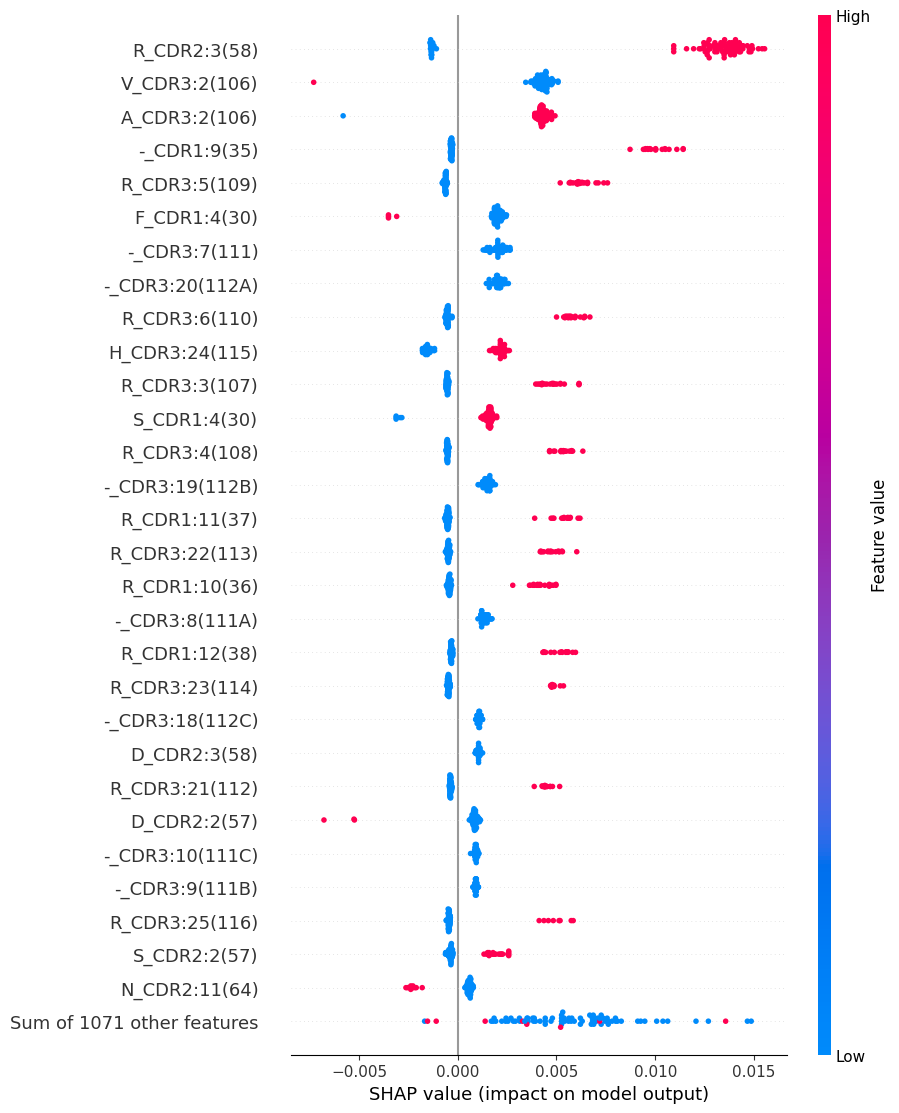

In [23]:
k_conf = 100
top_idx = np.argsort(-y_scores_test)[:k_conf]
top_pos_idx = top_idx[y_test[top_idx] == 1]

sv_conf_pos = sv[top_pos_idx]
X_conf_pos_df = X_test_df.iloc[top_pos_idx]

print("High-conf & label=1:", len(top_pos_idx))
shap.plots.beeswarm(sv_conf_pos, max_display=30)

In [24]:
def anarcii_aa_heatmap(
    shap_values_matrix,  # (n_samples, D)
    X_df,                # (n_samples, D) dataframe with SAME column order as feature_names
    feature_names,       # length D, like "A_CDR3:6(105)" etc.
    aa_alphabet="ACDEFGHIKLMNPQRSTVWY-",
    agg="mean_abs",      # "mean_abs" | "mean_signed" | "pos_only_mean_abs"
    drop_non_aa=True,    # drops Extra* channels
    sort_positions=True
):
    # Parse: "{AA}_{CDR}:{idx}({anarcii})"  -> AA and anarcii label
    # Example: "W_CDR3:6(105B)"
    pat = re.compile(r"^([A-Z\-])_.*\((\d+[A-Z]?)\)$")

    rows = []
    for j, fn in enumerate(feature_names):
        m = pat.match(fn)
        if not m:
            if drop_non_aa:
                continue
            else:
                continue
        aa, pos = m.group(1), m.group(2)
        if aa not in aa_alphabet:
            continue
        rows.append((j, pos, aa))

    if len(rows) == 0:
        raise ValueError("No AA-position features parsed. Check your feature name format.")

    idxs = np.array([r[0] for r in rows], dtype=int)
    pos_list = [r[1] for r in rows]
    aa_list  = [r[2] for r in rows]

    # Slice to AA channels only
    shap_sub = shap_values_matrix[:, idxs]
    X_sub    = X_df.iloc[:, idxs].to_numpy()

    # Aggregate
    if agg == "mean_abs":
        val = np.mean(np.abs(shap_sub), axis=0)
    elif agg == "mean_signed":
        val = np.mean(shap_sub, axis=0)
    elif agg == "pos_only_mean_abs":
        # only consider samples where that AA feature is "on" (one-hot == 1)
        val = np.zeros(shap_sub.shape[1], dtype=float)
        for k in range(shap_sub.shape[1]):
            mask = X_sub[:, k] > 0.5
            val[k] = np.mean(np.abs(shap_sub[mask, k])) if mask.any() else 0.0
    else:
        raise ValueError("agg must be one of: mean_abs, mean_signed, pos_only_mean_abs")

    df_long = pd.DataFrame({"pos": pos_list, "aa": aa_list, "val": val})

    # Pivot into heatmap table
    heat = df_long.pivot_table(index="pos", columns="aa", values="val", aggfunc="mean", fill_value=0.0)

    # Ensure AA column order
    aa_order = [a for a in aa_alphabet if a in heat.columns]
    heat = heat.reindex(columns=aa_order)

    # Sort positions numerically (27, 27A, 28, ...)
    if sort_positions:
        def pos_key(p):
            m = re.match(r"(\d+)([A-Z]?)", str(p))
            return (int(m.group(1)), m.group(2) or "")
        heat = heat.reindex(sorted(heat.index, key=pos_key))

    # Plot
    plt.figure(figsize=(max(8, 0.35*len(aa_order)), max(6, 0.25*heat.shape[0])))
    im = plt.imshow(heat.to_numpy(), aspect="auto")
    plt.colorbar(im, label=f"SHAP ({agg})")

    plt.xticks(np.arange(len(aa_order)), aa_order, rotation=0)
    plt.yticks(np.arange(heat.shape[0]), heat.index)

    plt.xlabel("Amino acid")
    plt.ylabel("ANARCII / IMGT position")
    plt.title("ANARCII position × amino acid SHAP heatmap")
    plt.tight_layout()
    plt.show()

    return heat  # dataframe for further use

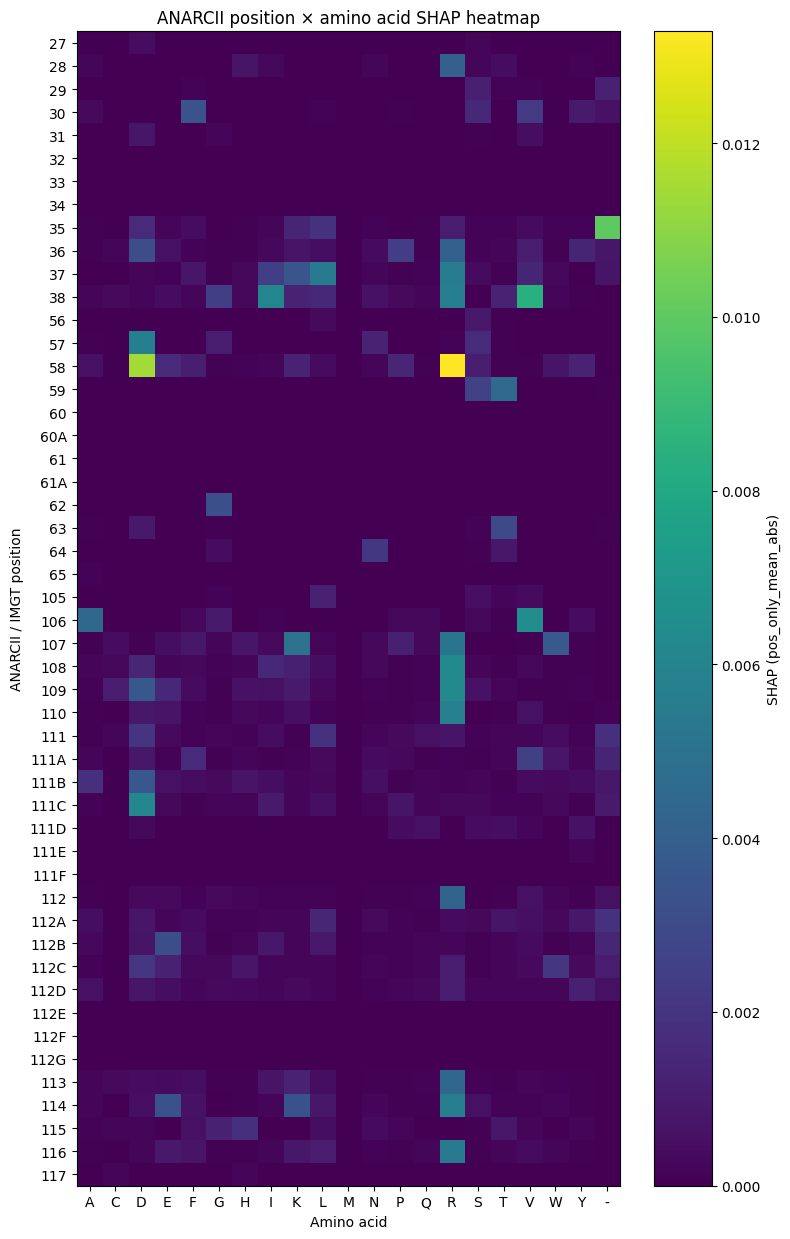

In [25]:
# sv is your shap.Explanation for class 1 (after you sliced it to class 1)
# shap_values_matrix is (n_test, D)
# X_test_df is your test dataframe with the same columns

heat = anarcii_aa_heatmap(
    shap_values_matrix=shap_values_matrix,
    X_df=X_test_df,
    feature_names=feature_names,
    agg="pos_only_mean_abs"   # usually most interpretable for one-hot
)

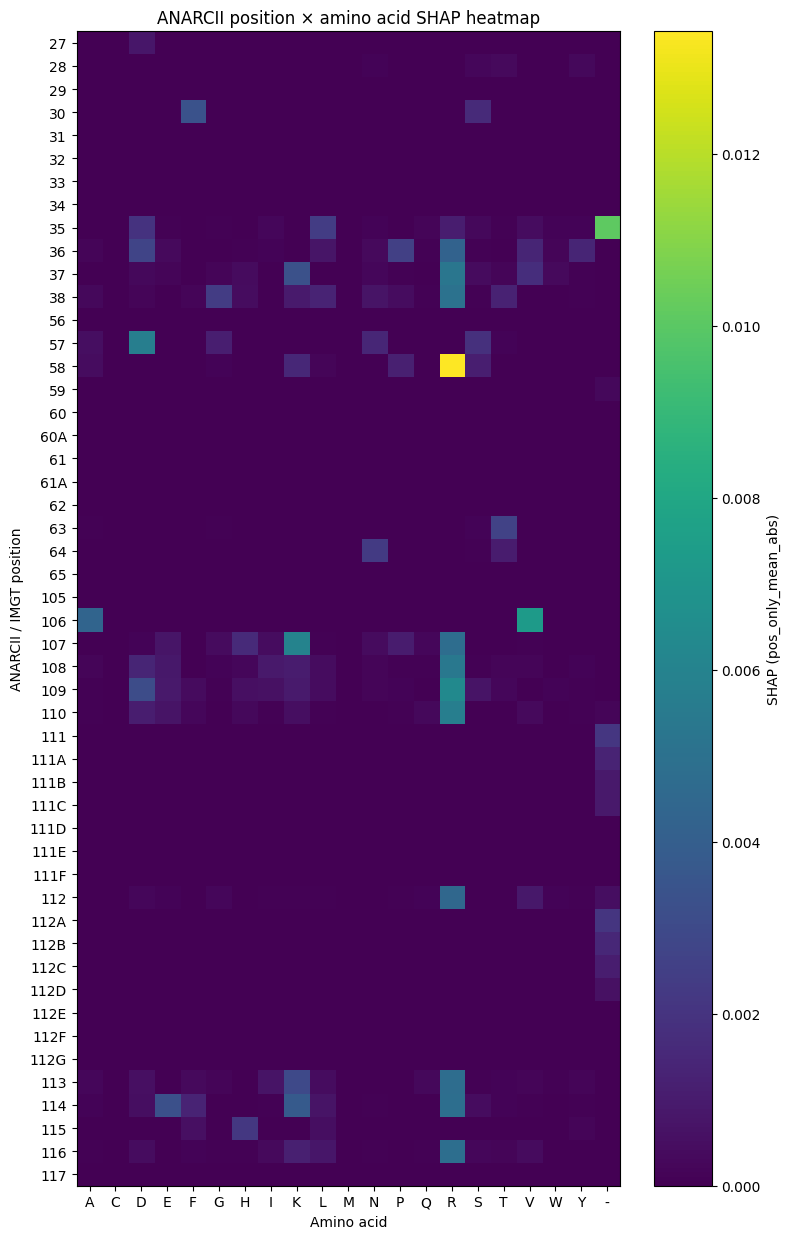

In [32]:
k_conf = 100
top_idx = np.argsort(-y_scores_test)[:k_conf]

heat_conf = anarcii_aa_heatmap(
    shap_values_matrix=shap_values_matrix[top_idx],
    X_df=X_test_df.iloc[top_idx],
    feature_names=feature_names,
    agg="pos_only_mean_abs"
)

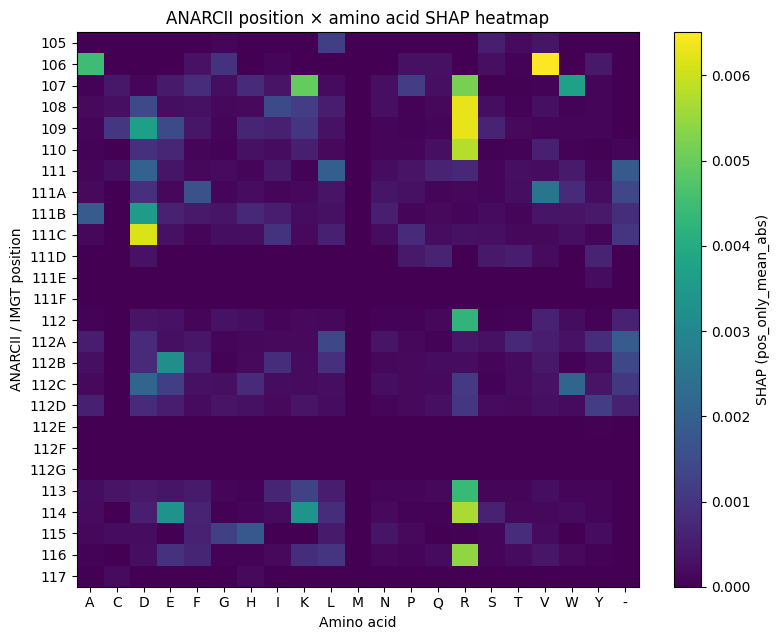

In [33]:
cdr3_positions = set([str(p) for p in anarcii_cdr_cols if num_part(p) is not None and 105 <= num_part(p) <= 117])

# select columns belonging to those positions
pos_pat = re.compile(r"\((\d+[A-Z]?)\)$")
keep_cols = []
keep_names = []
for j, fn in enumerate(feature_names):
    m = pos_pat.search(fn)
    if m and m.group(1) in cdr3_positions:
        keep_cols.append(j)
        keep_names.append(fn)

heat_cdr3 = anarcii_aa_heatmap(
    shap_values_matrix=shap_values_matrix[:, keep_cols],
    X_df=X_test_df.iloc[:, keep_cols],
    feature_names=keep_names,
    agg="pos_only_mean_abs"
)

Get the predicted + true label 1

In [34]:
top100_df =  test_df.iloc[top_idx].copy()
top100_df["y_true"] = y_test[top_idx]
top100_df["y_score"] = y_scores_test[top_idx]
top100_df["pred_label"] = y_pred_test[top_idx]


In [35]:
tp_top100_df = top100_df[
    (top100_df["y_true"] == 1) & (top100_df["pred_label"] == 1)
].copy()
tp_top100_df = tp_top100_df.rename(columns={"y_score": "pred_score"})


In [36]:
export_df = tp_top100_df[[
    "Cluster_name",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence"
]]



In [37]:
export_df.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\Predictions\regularized_position-aware_ohe.csv", index=False)
print("Saved only confident predictions to confident_predictions.csv")
print("Number of confident predictions:", len(export_df))


Saved only confident predictions to confident_predictions.csv
Number of confident predictions: 84
